# Language Models for Text Classification 

## 0. Setup

In [1]:
import os
import re
import time
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI
from groq import Groq
from mistralai.client import Mistral
from sklearn.model_selection import train_test_split


In [2]:
%env GROQ_API_KEY='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'
%env MISTRAL_API_KEY='pojygBcty1joDr7csFHKQIJTVFHQCRTX'

env: GROQ_API_KEY='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'
env: MISTRAL_API_KEY='pojygBcty1joDr7csFHKQIJTVFHQCRTX'


In [37]:
SEED = 2026

# Small subsets keep the demo fast and avoid exhausting free quotas.
TRAIN_SUBSET = 50
TEST_SUBSET = 50

LABELS = [
    "Anthropic",
    "Google",
    "Human",
    "Meta",
    "OpenAI"
]

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
MISTRAL_API_KEY = os.getenv("MISTRAL_API_KEY")

print(f"Groq key loaded: {GROQ_API_KEY is not None}")
print(f"Mistral key loaded: {MISTRAL_API_KEY is not None}")

#Groq Models
GROQ_MODEL1 = "llama-3.1-8b-instant"
GROQ_MODEL2 = "llama-3.3-70b-versatile"

#Mistral Models
MISTRAL_MODEL1 = "mistral-large-latest"
MISTRAL_MODEL2 = "mistral-medium"
MISTRAL_MODEL3 = "mistral-large"



#OPENAI_MODEL = "gpt-4o-mini"

# groq_client = Groq(api_key=GROQ_API_KEY)
# mistral_client = Mistral(api_key=MISTRAL_API_KEY)

groq_client = Groq(api_key='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')
mistral_client = Mistral(api_key='pojygBcty1joDr7csFHKQIJTVFHQCRTX')

Groq key loaded: True
Mistral key loaded: True


## 1. Carregamento e Pré-processamento dos Dados

In [ ]:
df = pd.read_csv("data/train.csv", sep=";")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.strip()

df["clean_text"] = df["Text"].apply(clean_text)

df_train, df_test = train_test_split(df, test_size=0.5, random_state=SEED, stratify=df["Label"])

#  reduzir custo API
df_train = df_train.sample(n=TRAIN_SUBSET, random_state=SEED)
df_test = df_test.sample(n=TEST_SUBSET, random_state=SEED)

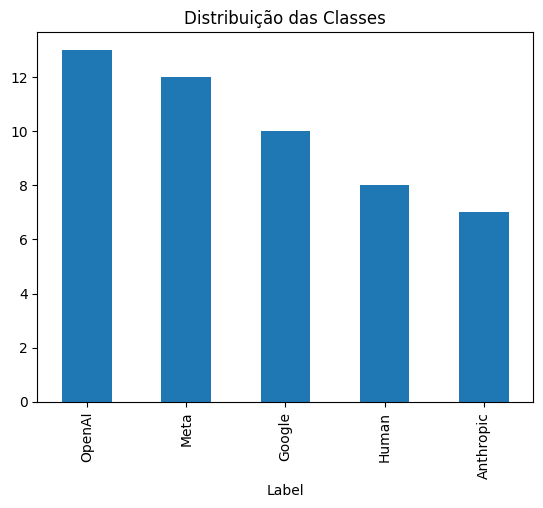

In [5]:
df_train["Label"].value_counts().plot(kind="bar", title="Distribuição das Classes")
plt.show()

## 2. Build prompts

Definição do *prompt* para classificar textos.

zero-shot vs few-shot

In [6]:
def build_zero_shot_prompt(example):
    prompt = f"""
You are a strict classifier.

Possible labels:
Anthropic, Google, Human, Meta, OpenAI

Return ONLY one label.

Text:\n
{example["clean_text"]}
"""
    return prompt.strip()

In [7]:
support_examples = df_train.sample(n=5, random_state=SEED).to_dict(orient="records")

def format_example(ex):
    return f"""
Text: "{ex["clean_text"]}"
Label: {ex["Label"]}
"""

def build_few_shot_prompt(example, support_examples):
    support_block = ""

    for support_example in support_examples:
        support_block += format_example(support_example)
    
    prompt = f"""
You are a text classifier.

Possible labels:
Anthropic, Google, Human, Meta, OpenAI

Examples:
{support_block}

Now classify:

Text:
{example["clean_text"]}

Return ONE and ONLY label.
"""
    return prompt.strip()

## 3. API helpers

In [8]:
def ask_groq(prompt, model=GROQ_MODEL1):
    response = groq_client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=10,
    )
    
    print(response)

    return response.choices[0].message.content

In [ ]:
def ask_mistral(prompt, model=MISTRAL_MODEL1):
    response = mistral_client.chat.complete(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=10,
    )
    
    print(response)

    return response.choices[0].message.content

In [10]:
VALID_LABELS = set(LABELS)

def normalize_prediction(text):
    if text is None:
        return None

    text = text.strip()

    if text in VALID_LABELS:
        return text

    for label in VALID_LABELS:
        if label.lower() in text.lower():
            return label
            
    return None

In [11]:
def evaluate_predictions(predictions, gold_labels):
    rows = []
    for gold_label, prediction in zip(gold_labels, predictions):
        rows.append({
            "gold_label": gold_label,
            "prediction": prediction,
            "correct":    prediction == gold_label,
        })
    return pd.DataFrame(rows)

## 4. Zero-shot classification

In [12]:
def run_experiment(
    dataset_split,
    ask_fn,
    model_name,
    prompt_builder,
    support_examples=None,
    sleep_seconds=0.8,
):

    predictions, raw_outputs = [], []

    for example in dataset_split:
        try:
            prompt = (
                prompt_builder(example, support_examples)
                if support_examples
                else prompt_builder(example)
            )
            raw  = ask_fn(prompt, model=model_name)
            pred = normalize_prediction(raw)
            raw_outputs.append(raw)
            predictions.append(pred)
        except Exception as e:
            print(f"Error: {e}")
            raw_outputs.append(None)
            predictions.append(None)

        time.sleep(sleep_seconds)

    return predictions, raw_outputs

In [15]:
gold_test = df_test["Label"].tolist()

zs_groq_preds1, zs_groq_raw1 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=GROQ_MODEL1,
    prompt_builder=build_zero_shot_prompt,
)

ChatCompletion(id='chatcmpl-e4b69571-d706-45b8-95bc-0b7b145b5d5a', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Human', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774366327, model='llama-3.1-8b-instant', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_03e8423237', usage=CompletionUsage(completion_tokens=2, prompt_tokens=154, total_tokens=156, completion_time=0.007601326, completion_tokens_details=None, prompt_time=0.010238258, prompt_tokens_details=None, queue_time=0.01895159, total_time=0.017839584), usage_breakdown=None, x_groq=XGroq(id='req_01kmg7k0h7ftt83qk1ehef6cyn', debug=None, seed=699716089, usage=None))
ChatCompletion(id='chatcmpl-07019215-ff34-43f8-8a80-9e8bea9f6ed4', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Human', role='assistant', ann

In [28]:
zs_groq_preds2, zs_groq_raw2 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=GROQ_MODEL2,
    prompt_builder=build_zero_shot_prompt,
)

ChatCompletion(id='chatcmpl-bdb060b2-3e02-4d73-bd18-38bb0c450282', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='OpenAI', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774374811, model='llama-3.3-70b-versatile', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_f8b414701e', usage=CompletionUsage(completion_tokens=3, prompt_tokens=154, total_tokens=157, completion_time=0.015342207, completion_tokens_details=None, prompt_time=0.00792282, prompt_tokens_details=None, queue_time=0.048267376, total_time=0.023265027), usage_breakdown=None, x_groq=XGroq(id='req_01kmgfny48ew68vs51230npwjv', debug=None, seed=116010085, usage=None))
ChatCompletion(id='chatcmpl-904050a0-cc7f-48ed-82da-a20a8d4ccf1e', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='OpenAI', role='assistant'

In [32]:
groq_eval1 = evaluate_predictions(zs_groq_preds1, gold_test)
groq_eval2 = evaluate_predictions(zs_groq_preds2, gold_test)

print("Groq:")
display(groq_eval1)
display(groq_eval2)

Groq:


,gold_label,prediction,correct
0,Google,Human,False
1,OpenAI,Human,False
2,Anthropic,Human,False
3,Human,Human,True
4,Anthropic,Human,False
5,Meta,Human,False
6,OpenAI,Human,False
7,Anthropic,Meta,False
8,Anthropic,Human,False
9,Anthropic,Human,False


,gold_label,prediction,correct
0,Google,OpenAI,False
1,OpenAI,OpenAI,True
2,Anthropic,Human,False
3,Human,Human,True
4,Anthropic,Human,False
5,Meta,OpenAI,False
6,OpenAI,OpenAI,True
7,Anthropic,Human,False
8,Anthropic,Human,False
9,Anthropic,Human,False


In [38]:
zs_mistral_preds1, zs_mistral_raw1 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_mistral,
    model_name=MISTRAL_MODEL1,
    prompt_builder=build_zero_shot_prompt,
)

id='86f10fdbebb64513a52d1be55a39c65d' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=124, completion_tokens=2, total_tokens=126, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774375528 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='a17fc3aec1ab4edcb01a4932360821fb' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=50, completion_tokens=2, total_tokens=52, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774375530 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='f3aa9c0e7eb448d8a624c9519adc1e1a' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=54, completion_tokens=2, total_tokens=56, prompt_audio

In [29]:
zs_mistral_preds2, zs_mistral_raw2 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_mistral,
    model_name=MISTRAL_MODEL2,
    prompt_builder=build_zero_shot_prompt,
)

id='19d104e0bc914c0b8e2ff9cc20b8c2b3' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=124, completion_tokens=2, total_tokens=126, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774375164 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='e0ac180ce66e4562b247414846cd5042' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=50, completion_tokens=2, total_tokens=52, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774375165 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='77498a505e4540a1b926f90b7cd42e8c' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=54, completion_tokens=2, total_tokens=56, prompt_audio_seconds=Unset(), 

In [39]:
mistral_eval1 = evaluate_predictions(zs_mistral_preds1, gold_test)
mistral_eval2 = evaluate_predictions(zs_mistral_preds2, gold_test)

print("Mistral:")
display(mistral_eval1)
display(mistral_eval2)

Mistral:


,gold_label,prediction,correct
0,Google,Human,False
1,OpenAI,Human,False
2,Anthropic,Human,False
3,Human,Human,True
4,Anthropic,Human,False
5,Meta,Human,False
6,OpenAI,Human,False
7,Anthropic,Human,False
8,Anthropic,Human,False
9,Anthropic,Human,False


,gold_label,prediction,correct
0,Google,Human,False
1,OpenAI,Human,False
2,Anthropic,Human,False
3,Human,Human,True
4,Anthropic,Human,False
5,Meta,Human,False
6,OpenAI,Human,False
7,Anthropic,Human,False
8,Anthropic,Human,False
9,Anthropic,Human,False


## 5. Few-shot classification

In few-shot prompting, we include a small number of labeled examples in the prompt.

In [40]:
support_examples = []
seen = set()

for _, row in df_train.iterrows():
    label = row["Label"]
    if label not in seen:
        support_examples.append(row.to_dict())
        seen.add(label)
    if len(seen) == len(LABELS):  
        break

print(f"Support set size: {len(support_examples)} — labels: {seen}\n")


for ex in support_examples:
    print(ex["Label"])
    print(format_example(ex))
    print("-" * 80)

Support set size: 5 — labels: {'Human', 'Google', 'Anthropic', 'OpenAI', 'Meta'}

Anthropic

Text: "having polar bonds may make a covalent compound polar"
Label: Anthropic

--------------------------------------------------------------------------------
Meta

Text: "the term  ghost sharks  refers to the deep sea chimaeras  which are cartilaginous fish characterized by their unique  filter feeding behavior and distinctive body shape  these ancient creatures have evolved over millions of years to thrive in the dark depths of the ocean  where they feed on plankton and small organisms  chimaeras possess a long snout and jaws lined with tiny teeth that help them capture prey"
Label: Meta

--------------------------------------------------------------------------------
Google

Text: "migration is the movement of animals from one place to another  it s often seasonal  driven by factors like food availability  breeding grounds  or climate  migration can be short distance or cover vast distance

In [41]:
gold_test = df_test["Label"].tolist()

fs_groq_preds1, fs_groq_raw = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=GROQ_MODEL1,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples,
)

ChatCompletion(id='chatcmpl-841b24d6-95ca-4233-8595-561b93c2bbf1', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Anthropic', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774375677, model='llama-3.1-8b-instant', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_dd2ecd7b1d', usage=CompletionUsage(completion_tokens=3, prompt_tokens=572, total_tokens=575, completion_time=0.00751751, completion_tokens_details=None, prompt_time=0.035196581, prompt_tokens_details=None, queue_time=0.045168188, total_time=0.042714091), usage_breakdown=None, x_groq=XGroq(id='req_01kmgggb51fxz9by2vtvh2ayx7', debug=None, seed=972623083, usage=None))
ChatCompletion(id='chatcmpl-d1f77743-0ba1-4194-abb7-a58884b1a4b7', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Anthropic', role='assista

In [51]:

fs_groq_preds2, fs_groq_raw = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=GROQ_MODEL2,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples,
)

ChatCompletion(id='chatcmpl-170df1f8-2fc7-4750-931e-b234247998c0', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='OpenAI', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774376634, model='llama-3.3-70b-versatile', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_ce7bc1685b', usage=CompletionUsage(completion_tokens=3, prompt_tokens=572, total_tokens=575, completion_time=0.015404826, completion_tokens_details=None, prompt_time=0.339510664, prompt_tokens_details=None, queue_time=0.058553873, total_time=0.35491549), usage_breakdown=None, x_groq=XGroq(id='req_01kmghdhpzfb6rvbmqhqpt00hx', debug=None, seed=1668219100, usage=None))
Error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01km2vj9kzew8rpq8t3vdfy4rd` service tier `on_demand` on tokens per d

KeyboardInterrupt: 

In [ ]:
df_fs_groq1    = evaluate_predictions(fs_groq_preds1,    gold_test)
df_fs_groq2    = evaluate_predictions(fs_groq_preds2,    gold_test)

print("=== Groq few-shot ===")
display(df_fs_groq1)
display(df_fs_groq2)

=== Groq few-shot ===


,gold_label,prediction,correct
0,Google,Anthropic,False
1,OpenAI,Anthropic,False
2,Anthropic,Anthropic,True
3,Human,Human,True
4,Anthropic,Anthropic,True
5,Meta,OpenAI,False
6,OpenAI,Human,False
7,Anthropic,Anthropic,True
8,Anthropic,Anthropic,True
9,Anthropic,Anthropic,True


In [45]:
fs_mistral_preds1, fs_mistral_raw1 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_mistral,
    model_name=MISTRAL_MODEL1,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples,
)

id='602007c4d2f8416b8be090e2106660da' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=533, completion_tokens=3, total_tokens=536, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774375975 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='OpenAI', tool_calls=None, prefix=False), finish_reason='stop')]
id='cbc514d8eb744e8fa38760c71e3dc3e1' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=459, completion_tokens=3, total_tokens=462, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774375976 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='OpenAI', tool_calls=None, prefix=False), finish_reason='stop')]
id='f379a3dd9cbe483fbf714b67267ccf1c' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=463, completion_tokens=2, total_tokens=465, prompt

In [46]:
fs_mistral_preds2, fs_mistral_raw2 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_mistral,
    model_name=MISTRAL_MODEL2,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples,
)

id='1fe3776f2008402b969b47d7df951ce2' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=533, completion_tokens=2, total_tokens=535, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774376060 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Meta', tool_calls=None, prefix=False), finish_reason='stop')]
id='b165da37d1f14c8d814f88d8e59bfdfc' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=459, completion_tokens=2, total_tokens=461, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774376061 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Meta', tool_calls=None, prefix=False), finish_reason='stop')]
id='eec9a38c5fd04f479e465ef66af46dc1' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=463, completion_tokens=2, total_tokens=465, prompt_audio_seconds=Unset()

In [47]:
df_fs_mistral1 = evaluate_predictions(fs_mistral_preds1, gold_test)
df_fs_mistral2 = evaluate_predictions(fs_mistral_preds2, gold_test)


print("\n=== Mistral few-shot ===")
display(df_fs_mistral1)
display(df_fs_mistral2)


=== Mistral few-shot ===


,gold_label,prediction,correct
0,Google,OpenAI,False
1,OpenAI,OpenAI,True
2,Anthropic,Human,False
3,Human,Human,True
4,Anthropic,OpenAI,False
5,Meta,OpenAI,False
6,OpenAI,Human,False
7,Anthropic,Human,False
8,Anthropic,Human,False
9,Anthropic,Human,False


,gold_label,prediction,correct
0,Google,Meta,False
1,OpenAI,Meta,False
2,Anthropic,Meta,False
3,Human,Anthropic,False
4,Anthropic,Anthropic,True
5,Meta,Anthropic,False
6,OpenAI,OpenAI,True
7,Anthropic,Anthropic,True
8,Anthropic,Meta,False
9,Anthropic,Google,False


## 7. Comparação zero-shot vs few-shot



,Setting,Accuracy
0,Groq1 zero-shot,0.10
1,Groq1 few-shot,0.34
2,Groq2 zero-shot,0.24
3,Mistral1 zero-shot,0.14
4,Mistral1 few-shot,0.18
5,Mistral2 zero-shot,0.06
6,Mistral2 few-shot,0.18


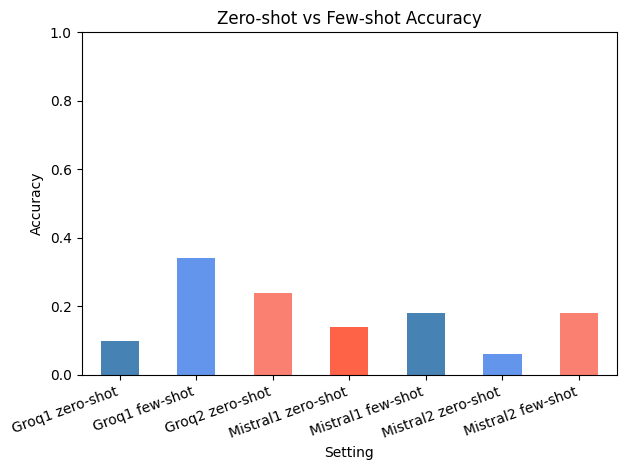

In [52]:
def accuracy(preds, gold_labels):
    if not gold_labels:
        return 0.0
    return sum(p == g for p, g in zip(preds, gold_labels)) / len(gold_labels)


results = {
    "Groq1 zero-shot":    accuracy(zs_groq_preds1,    gold_test),
    "Groq1 few-shot":     accuracy(fs_groq_preds1,    gold_test),
    
    "Groq2 zero-shot":    accuracy(zs_groq_preds2,    gold_test),
    #"Groq2 few-shot":     accuracy(fs_groq_preds2,    gold_test),
    
    "Mistral1 zero-shot": accuracy(zs_mistral_preds1,  gold_test),
    "Mistral1 few-shot":  accuracy(fs_mistral_preds1,  gold_test),
    
    "Mistral2 zero-shot": accuracy(zs_mistral_preds2,  gold_test),
    "Mistral2 few-shot":  accuracy(fs_mistral_preds2,  gold_test),
}

results_df = pd.DataFrame(list(results.items()), columns=["Setting", "Accuracy"])
display(results_df)

results_df.set_index("Setting")["Accuracy"].plot(
    kind="bar",
    title="Zero-shot vs Few-shot Accuracy",
    ylim=(0, 1),
    color=["steelblue", "cornflowerblue", "salmon", "tomato"],
)
plt.ylabel("Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()